In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras import regularizers
import optuna
import shap

In [2]:
# For reproducibility add the same seed. "42" is the standard value.
random_number_seed = 42
np.random.seed(random_number_seed)
keras.utils.set_random_seed(random_number_seed)

#### Help functions

In [3]:
# Function that plots the training and validation for the different epochs.
from matplotlib import legend


def training_validation_history_plot(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")
    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch', fontsize=16)
    axes[0].set_ylabel('Loss (MSE)', fontsize=16)
    # axes[0].set_title('Model Loss')
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    legend = axes[0].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    # MAE plot
    axes[1].plot(history.history['mae'], label='Training MAE')
    axes[1].plot(history.history['val_mae'], label='Validation MAE')
    axes[1].set_xlabel('Epoch', fontsize=16)
    axes[1].set_ylabel('MAE', fontsize=16)
    # axes[1].set_title('Model MAE')
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    legend = axes[1].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    plt.tight_layout()
    plt.show() 

# Performance metrics on the training set
def performance_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred):
    mse_train  = mean_squared_error(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    r2_train   = r2_score(Y_train, Y_train_pred)
    
    print(f"\nPerformance metrics on the training set:")
    print(f"R² Score: {r2_train:.4f}")
    print(f"MSE:      {mse_train:.2f}")
    print(f"RMSE:     {rmse_train:.2f}%")
    print(f"MAE:      {mae_train:.2f}%")
    
    # Performance metrics on testing set
    mse_test  = mean_squared_error(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_test   = r2_score(Y_test, Y_test_pred)
    
    print(f"\nPerformance metrics on testing set:")
    print(f"R² Score: {r2_test:.4f}")
    print(f"MSE:      {mse_test:.2f}")
    print(f"RMSE:     {rmse_test:.2f}%")
    print(f"MAE:      {mae_test:.2f}%")

    return mse_train, rmse_train, mae_train, r2_train, mse_test, rmse_test, mae_test, r2_test

def parity_plot(Y_train, Y_train_pred, Y_test, Y_test_pred):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")

    # Calculate the metrics
    r2_test   = r2_score(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(Y_test, Y_test_pred))
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_train  = r2_score(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    
    # Test set parity plot
    axes[0].scatter(Y_test, Y_test_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = min(Y_test.min(), Y_test_pred.min())
    max_val = max(Y_test.max(), Y_test_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[0].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    test_metrics_label = f'R² = {r2_test:.3f}\nRMSE = {rmse_test:.2f}%\nMAE = {mae_test:.2f}%'
    
    axes[0].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[0].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[0].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=test_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[0].set_xlim(-5, 105)
    axes[0].set_ylim(-5, 105)
    
    # Training set parity plot
    axes[1].scatter(Y_train, Y_train_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = min(Y_train.min(), Y_train_pred.min())
    max_val = max(Y_train.max(), Y_train_pred.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[1].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    train_metrics_label = f'R² = {r2_train:.3f}\nRMSE = {rmse_train:.2f}%\nMAE = {mae_train:.2f}%'
    
    axes[1].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[1].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[1].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=train_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[1].set_xlim(-5, 105)
    axes[1].set_ylim(-5, 105)
    
    plt.tight_layout()
    plt.show()

def parity_plot_single(Y, Y_pred):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.set_theme(style="ticks")

    # Calculate the metrics
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    mae  = np.mean(np.abs(Y - Y_pred))

    ax.scatter(Y, Y_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = 0
    max_val = 100
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    ax.fill_between([min_val, max_val],
                    [min_val - 10, max_val - 10],
                    [min_val + 10, max_val + 10],
                    alpha=0.2, color='gray', label='±10% Error')

    metrics_label = f'RMSE = {rmse:.2f}%\nMAE = {mae:.2f}%'

    ax.set_xlabel('Experimental Yield (%)', fontsize=16)
    ax.set_ylabel('Predicted Yield (%)', fontsize=16)
    ax.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)

    legend = ax.legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0, 0), 1, 1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=metrics_label),
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)

    plt.tight_layout()
    plt.show()

def residual_analysis(Y_test, Y_test_pred):

    residuals = Y_test - Y_test_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Residuals vs Predicted
    axes[0].scatter(Y_test_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Predicted Yield (%)')
    axes[0].set_ylabel('Residual (Actual - Predicted) (%)')
    axes[0].set_title('Residuals vs Predicted Values')
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of residuals
    axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Residual (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Distribution of Residuals\nMean = {residuals.mean():.2f}%, Std = {residuals.std():.2f}%')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Data preprocessing

##### Data Loading

In [ ]:
# Loading the Reizman data
full_data_path=  r"Reizman_database - COMPLETE - BASELINE.xlsx"
df = pd.read_excel(full_data_path)

# Loading the ligand descriptor data from KRAKEN database
kraken_data_path = r"KRAKEN - Ligand descriptor database.xlsx"
df_kraken = pd.read_excel(kraken_data_path, sheet_name='dft_targets_SI')

In [6]:
all_descriptor_list = df_kraken.columns.tolist()
print(df_kraken.columns.tolist())

['ID', 'SMILES', 'vmin_vmin_boltz', 'vmin_r_boltz', 'fmo_e_homo_boltz', 'fmo_e_lumo_boltz', 'fmo_mu_boltz', 'fmo_eta_boltz', 'fmo_omega_boltz', 'somo_ra_boltz', 'somo_rc_boltz', 'nbo_P_boltz', 'nbo_P_ra_boltz', 'spindens_P_ra_boltz', 'nbo_P_rc_boltz', 'spindens_P_rc_boltz', 'nmr_P_boltz', 'nmrtens_sxx_P_boltz', 'nmrtens_syy_P_boltz', 'nmrtens_szz_P_boltz', 'efg_amp_P_boltz', 'efgtens_xx_P_boltz', 'efgtens_yy_P_boltz', 'efgtens_zz_P_boltz', 'nuesp_P_boltz', 'E_solv_cds_boltz', 'nbo_lp_P_percent_s_boltz', 'nbo_lp_P_occ_boltz', 'nbo_lp_P_e_boltz', 'nbo_bd_e_max_boltz', 'nbo_bd_e_avg_boltz', 'nbo_bds_e_min_boltz', 'nbo_bds_e_avg_boltz', 'nbo_bd_occ_min_boltz', 'nbo_bd_occ_avg_boltz', 'nbo_bds_occ_max_boltz', 'nbo_bds_occ_avg_boltz', 'E_solv_total_boltz', 'E_solv_elstat_boltz', 'E_oxidation_boltz', 'E_reduction_boltz', 'fukui_p_boltz', 'fukui_m_boltz', 'vbur_vtot_boltz', 'vbur_ratio_vbur_vtot_boltz', 'Pint_P_int_boltz', 'Pint_dP_boltz', 'Pint_P_min_boltz', 'Pint_P_max_boltz', 'volume_boltz'

##### QM features extraction from KRAKEN database and appending to DataFrame

In [7]:
# This code is to append descriptors from the KRAKEN database to the DataFrame.
# Selected ligand descriptors
descriptor_list = [
    'vbur_vbur_min',
    'nbo_lp_P_e_boltz',
    'vbur_vtot_boltz',
    'sterimol_L_boltz', 
    'fmo_e_homo_boltz',
    'nuesp_P_boltz'
]

all_steric_descriptor_list = [
    'sphericity_boltz',
    'surface_area_boltz',
    'volume_boltz',
    'pyr_P_boltz',
    'pyr_alpha_boltz',
    'sterimol_burB1_boltz',
    'sterimol_burB5_boltz',
    'sterimol_burL_boltz',
    'sterimol_B1_boltz',
    'sterimol_B5_boltz',
    'sterimol_L_boltz',
    'vbur_vbur_boltz',
    'vbur_max_delta_qvbur_boltz',
    'vbur_ovbur_max_boltz',
    'vbur_ovtot_max_boltz',
    'vbur_qvbur_max_boltz',
    'vbur_qvtot_max_boltz',
    'vbur_max_delta_qvtot_boltz',
    'vbur_ovbur_min_boltz',
    'vbur_ovtot_min_boltz',
    'vbur_qvbur_min_boltz',
    'vbur_qvtot_min_boltz',
    'vbur_vtot_boltz',
    'vbur_ratio_vbur_vtot_boltz',
    'vbur_near_vbur_boltz',
    'vbur_near_vtot_boltz',
    'vbur_far_vbur_boltz',
    'vbur_far_vtot_boltz'
]

selected_ligand_descriptor_list = [
    'sphericity_boltz',
    'vbur_vbur_boltz',
    'sterimol_burB5_boltz',
    'fmo_eta_boltz',
    'fmo_omega_boltz',
    'fukui_m_boltz'
]

selected_aryl_descriptor_list = [
    'aryl_LUMO',
    'aryl_Electrophilicity',
    'aryl_HOMO-LUMO gap',
]

selected_boron_descriptor_list = [
    'boron_HOMO',
    'boron_Nucleofugality',
    'boron_Chem. potential'
]

selected_solvent_descriptor_list = [
    'solvent_Dipole module',
    'solvent_G solv. in H2O',
    'solvent_Polarizability'
]

def append_ligand_descriptors(df, df_kraken, descriptor_list):
    # Get all the unique ligand smiles from the database
    unique_ligand_smiles = df['ligand_smiles'].unique()

    # Create a DataFrame from the KRAKEN database where only the SMILES from the dataset are in there
    df_kraken_filtered = df_kraken[df_kraken['SMILES'].isin(unique_ligand_smiles)]

    # As can be seen, the XanthPhos is not recognized, because it is not in the KRAKEN database
    df_kraken_filtered.shape

    # Create a dictionary from the KRAKEN database with the SMILES and descriptors
    dict_kraken = {}
    for idx, row in df_kraken_filtered.iterrows():
        smiles = row['SMILES']
        dict_kraken[smiles] = {desc: row[desc] for desc in descriptor_list}

    print(f"KRAKEN database dictionary: {dict_kraken} \n")

    # Iterate through the database with reactions and add the descriptors as columns
    for idx, row in df.iterrows():
        smiles = row['ligand_smiles']

        if smiles in dict_kraken:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = dict_kraken[smiles][desc]
        else:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = None
            print(f"Warning: {smiles} not found in KRAKEN database")

def select_aryl_boron_solvent_descriptors(df, selected_aryl_list, selected_boron_list, selected_solvent_list):
    selected_descriptors = []
    for desc in selected_aryl_list:
        if desc in df.columns and desc.startswith('aryl_'):
            selected_descriptors.append(desc)
    for desc in selected_boron_list:
        if desc in df.columns and desc.startswith('boron_'):
            selected_descriptors.append(desc)
    for desc in selected_solvent_list:
        if desc in df.columns and desc.startswith('solvent_'):
            selected_descriptors.append(desc)

    # Remove other aryl_ and boron_ columns not in the selected lists
    all_aryl_boron_solvent_cols = [col for col in df.columns if col.startswith('aryl_') or col.startswith('boron_') or col.startswith('solvent_')]
    cols_to_drop = [col for col in all_aryl_boron_solvent_cols if col not in selected_descriptors]
    df.drop(columns=cols_to_drop, inplace=True)
    
    return selected_descriptors

# call the function with chosen ligand descriptors
append_ligand_descriptors(df, df_kraken, selected_ligand_descriptor_list)

# Selecting the aryl and boron descriptors
selected_aryl_boron_descriptors = select_aryl_boron_solvent_descriptors(df, selected_aryl_descriptor_list, selected_boron_descriptor_list, selected_solvent_descriptor_list)

KRAKEN database dictionary: {'CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1': {'sphericity_boltz': 0.704737109, 'vbur_vbur_boltz': 105.5662868, 'sterimol_burB5_boltz': 7.439480407, 'fmo_eta_boltz': 0.193131047, 'fmo_omega_boltz': 0.03833597, 'fukui_m_boltz': 0.363743942999999}, 'COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.732618381, 'vbur_vbur_boltz': 101.0938553, 'sterimol_burB5_boltz': 7.15627618299999, 'fmo_eta_boltz': 0.196400018999999, 'fmo_omega_boltz': 0.033749737, 'fukui_m_boltz': 0.355754061}, 'CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.711352995999999, 'vbur_vbur_boltz': 107.8093841, 'sterimol_burB5_boltz': 7.238774196, 'fmo_eta_boltz': 0.197769897, 'fmo_omega_boltz': 0.03212394, 'fukui_m_boltz': 0.351437523}, 'CC(C)(C)P(C(C)(C)C)C(C)(C)C': {'sphericity_boltz': 0.889512, 'vbur_vbur_boltz': 65.12848283, 'sterimol_burB5_boltz': 4.894739112, 'fmo_eta_boltz': 0.25289, 'fmo_omega_boltz': 0.016170053, 'fukui_m_bol

### Feature engineering

##### Feature selection

In [8]:
# Additional data removal test
# df_remaining = df.sample(frac= 0.8, random_state = random_number_seed)
# df_removed = df.drop(df_remaining.index)

# Here, removed the datapoints with XanthPhos ligands as there are no descriptors for in the database.
df_remaining = df[df['ligand_smiles'] != '[H]P([H])c1cccc2c1Oc1ccccc1C2(C)C']

In [9]:
# Seperation of features (inputs) and targets (outputs) of the model
X = df_remaining.drop(['yield_pct', 'TON', 'case', 'experiment', 'number_aryl_halide',
                       'number_boron_species', 'ligand_smiles', 'catalyst',
                       'name_aryl_halide', 'smiles_aryl_halide', 'name_boron_species',
                      'smiles_boron_species', 'name_base', 'smiles_base', 'name_solvent',
                       'smiles_solvent'], axis = 1)
Y = df_remaining['yield_pct'].values

categorical_cols = ['name_aryl_halide', 'name_boron_species']
numerical_cols =  X.columns.tolist()

print("Features shape:", X.shape)
print("Features:", X.columns.tolist())
print("Target shape:", Y.shape)

Features shape: (327, 19)
Features: ['time_s', 'temp_c', 'cat_loading', 'aryl_HOMO-LUMO gap', 'aryl_LUMO', 'aryl_Electrophilicity', 'boron_HOMO', 'boron_Chem. potential', 'boron_Nucleofugality', 'solvent_Dipole module', 'solvent_G solv. in H2O', 'solvent_Polarizability', 'base_pka', 'ligand_sphericity_boltz', 'ligand_vbur_vbur_boltz', 'ligand_sterimol_burB5_boltz', 'ligand_fmo_eta_boltz', 'ligand_fmo_omega_boltz', 'ligand_fukui_m_boltz']
Target shape: (327,)


##### Train-test split

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=random_number_seed
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Input features: {X_train.shape[1]}")

Training set size: 261 samples
Test set size: 66 samples
Input features: 19


##### Transforming data based on categorical or numerical features

In [11]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ])

In [12]:
# Transform/Scale the data by using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after preprocessing. Just for verification and amount of features
feature_names = (numerical_cols)

print(f"\nProcessed feature matrix shape: {X_train_processed.shape}")
print(f"Feature names: {feature_names}")

# Scaling the target Y
# Also scale the target, because NN work better with scaled targets
Y_scaler = StandardScaler()
Y_train_scaled = Y_scaler.fit_transform(Y_train.reshape(-1, 1)).flatten()
Y_test_scaled = Y_scaler.transform(Y_test.reshape(-1, 1)).flatten()
print(f"\nTarget variable - Mean: {Y.mean():.2f}%, Std: {Y.std():.2f}%")


Processed feature matrix shape: (261, 19)
Feature names: ['time_s', 'temp_c', 'cat_loading', 'aryl_HOMO-LUMO gap', 'aryl_LUMO', 'aryl_Electrophilicity', 'boron_HOMO', 'boron_Chem. potential', 'boron_Nucleofugality', 'solvent_Dipole module', 'solvent_G solv. in H2O', 'solvent_Polarizability', 'base_pka', 'ligand_sphericity_boltz', 'ligand_vbur_vbur_boltz', 'ligand_sterimol_burB5_boltz', 'ligand_fmo_eta_boltz', 'ligand_fmo_omega_boltz', 'ligand_fukui_m_boltz']

Target variable - Mean: 45.41%, Std: 35.93%


###  One run test - Neural netowrk architecture

In [23]:
# Defining a feedforward neural network function
def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.2),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.2),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.2),
        Dense(1, activation='linear')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.0015), # Before 0.005
        loss='mse',
        metrics=['mae']
    )
    return model

# Create the model. Gives the input dimension of the training set. 
model = create_model(X_train_processed.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,593 (682.00 KB)

 Trainable params: 174,593 (682.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Model training

##### Callback functions

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,  # Reduced patience
    restore_best_weights=True,
    verbose=1,
    mode='min'
)
# Add learning rate reduction on plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.75,
    patience=20,
    min_lr=0.0001,
    verbose=1
)

##### Training the model

In [25]:
# Training the actual model
start_training_time = time.time()
history = model.fit(
    X_train_processed, Y_train_scaled,
    validation_split=0.2,
    epochs=200,  # Reduced epochs
    batch_size=30,  # Smaller batch size might help
    callbacks=[early_stop, reduce_lr],
    # callbacks=[reduce_lr],
    verbose=1,
    shuffle=True
)
end_training_time = time.time()
print(f"Total training time: {end_training_time - start_training_time:.2f}")

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 3.2374 - mae: 0.6322 - val_loss: 3.0318 - val_mae: 0.4836 - learning_rate: 0.0015
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.7324 - mae: 0.4244 - val_loss: 2.5115 - val_mae: 0.3703 - learning_rate: 0.0015
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.4745 - mae: 0.3990 - val_loss: 2.3551 - val_mae: 0.3910 - learning_rate: 0.0015
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.1917 - mae: 0.3555 - val_loss: 2.0838 - val_mae: 0.3470 - learning_rate: 0.0015
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.9858 - mae: 0.3306 - val_loss: 1.8755 - val_mae: 0.3026 - learning_rate: 0.0015
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.7876 - mae: 0.2952 - val_loss: 1.7091 - val_mae: 0.2943 - learning_rate: 0.0015
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.6256 - mae: 0.2870 - val_loss: 1.5578 - val_mae: 0.3193 - learning_rate: 0.0015
Epoch 8/200
7/7 ━━━━

##### Plot the training history and validation set

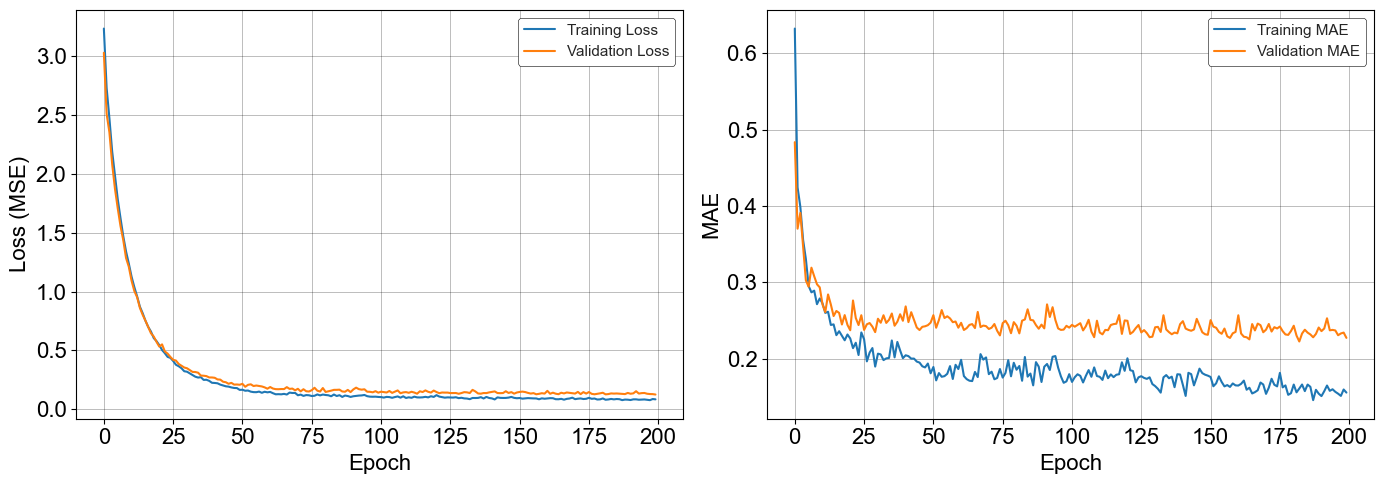

In [26]:
# Executing the function
training_validation_history_plot(history)

### One run test - Model evaluation

##### Calculating the predicted yield

In [27]:
# Prediction of training set
Y_train_pre_scaled = model.predict(X_train_processed)
Y_train_pred = Y_scaler.inverse_transform(Y_train_pre_scaled).flatten()

# Prediction of the yield value from the testing set based on the trained model. X_test is already scaled. And the Y_test_pred gets inverse scaled to get a yield value between 0-100%
Y_test_pred_scaled = model.predict(X_test_processed)
Y_test_pred = Y_scaler.inverse_transform(Y_test_pred_scaled).flatten()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


##### Performance metrics

In [28]:
performance_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred)


Performance metrics on the training set:
R² Score: 0.9584
MSE:      53.95
RMSE:     7.35%
MAE:      5.09%

Performance metrics on testing set:
R² Score: 0.8738
MSE:      157.60
RMSE:     12.55%
MAE:      8.65%


(53.95106087428048,
 np.float64(7.3451385878198705),
 np.float64(5.089430382105582),
 0.9584145270975484,
 157.59718289226043,
 np.float64(12.553771660033506),
 np.float64(8.645247422294183),
 0.8738068818886879)

##### Performance visualization

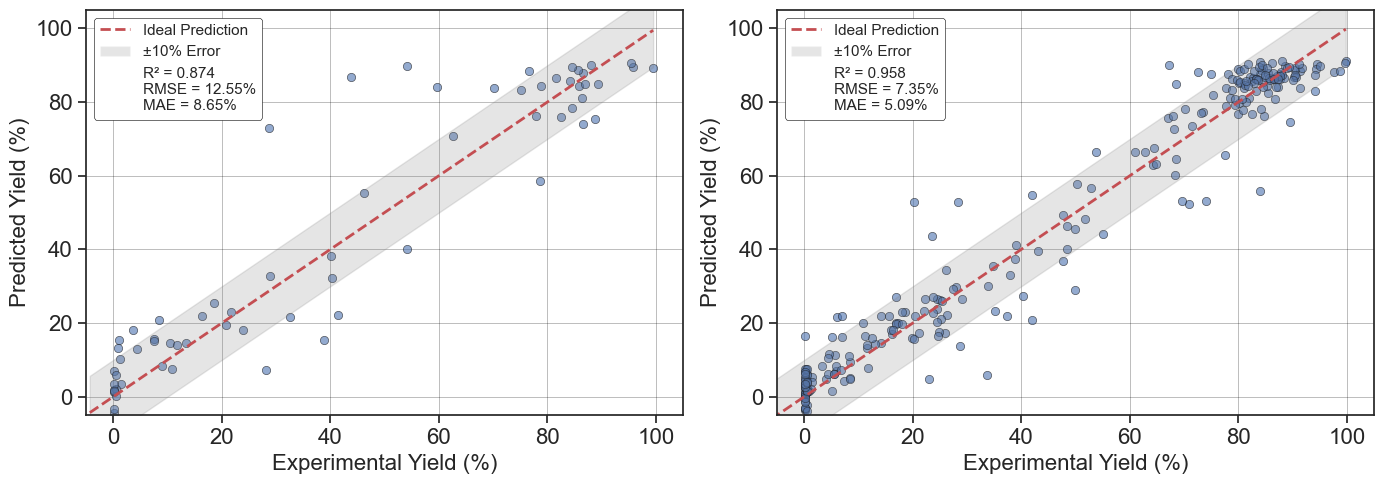

In [29]:
parity_plot(Y_train, Y_train_pred, Y_test, Y_test_pred)

In [ ]:
residual_analysis(Y_test, Y_test_pred)

### Final model - Hyperparameter optimization using Optuna

In [ ]:
# Defining the objecive function
def nn_objective(trial):
    # Defining the parameter range over which the optimization is performed. Int are continuous, and categorical not
    # Model architecture parameters
    n_layers = trial.suggest_int('n_layers', 1, 4)
    units_per_layer = [trial.suggest_int(f'units_l{i}', 32, 512, log=True) # Where units represent the # Nodes
                       for i in range(n_layers)]
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    l2_reg = trial.suggest_float('l2_reg', 1e-4, 1e-2, log=True)

    # Training parameters
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    # 5-fold cross validation for this trial. Here, the cross validations is explicitly defined again, because the hyperparameters change don't allow for predefined functions to be called
    cv = KFold(n_splits=5, shuffle=True, random_state=random_number_seed)
    fold_mse_scores = []

    # Iterating over the different folds
    for train_idx, val_idx in cv.split(X_train):
        X_fold_train_raw, X_fold_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        Y_fold_train_raw, Y_fold_val_raw = Y_train[train_idx], Y_train[val_idx]

        # Split training data further for early stopping
        X_inner_train_raw, X_inner_val_raw, Y_inner_train_raw, Y_inner_val_raw = train_test_split(
            X_fold_train_raw, Y_fold_train_raw, 
            test_size=0.2, 
            random_state=random_number_seed
        )

        # Preprocessing
        fold_preprocessor = ColumnTransformer(
            transformers=[('num', StandardScaler(), numerical_cols)]
        )
        X_inner_train = fold_preprocessor.fit_transform(X_inner_train_raw)
        X_inner_val = fold_preprocessor.transform(X_inner_val_raw)
        X_fold_val = fold_preprocessor.transform(X_fold_val_raw)

        # Scale Y (fit on inner training data only)
        fold_Y_scaler = StandardScaler()
        Y_inner_train = fold_Y_scaler.fit_transform(Y_inner_train_raw.reshape(-1, 1)).flatten()
        Y_inner_val = fold_Y_scaler.transform(Y_inner_val_raw.reshape(-1, 1)).flatten()
                
        # Build the NN model for this fold in this trial
        fold_model = keras.Sequential()
        fold_model.add(keras.layers.Input(shape=(X_inner_train.shape[1],)))
        for units in units_per_layer:
            fold_model.add(keras.layers.Dense(
                units, activation='relu',
                kernel_regularizer=regularizers.l2(l2_reg)
            ))
            fold_model.add(keras.layers.Dropout(dropout_rate))
        fold_model.add(keras.layers.Dense(1, activation='linear'))

        fold_model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='mse',
            metrics=['mae']
        )
        
        fold_early_stop = EarlyStopping(
            monitor='val_loss', patience=50,
            restore_best_weights=True, verbose=0
        )
        fold_reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.75,
            patience=20, min_lr=1e-5, verbose=0
        )
        # Training the fold model
        fold_model.fit(
            X_inner_train, Y_inner_train,
            validation_data=(X_inner_val, Y_inner_val), # On inner validation set for early stopping
            epochs=200, batch_size=batch_size,
            callbacks=[fold_early_stop, fold_reduce_lr],
            verbose=0
        )

        fold_val_pred_scaled = fold_model.predict(X_fold_val, verbose=0)
        fold_val_pred_original = fold_Y_scaler.inverse_transform(
            fold_val_pred_scaled.reshape(-1, 1)
        ).flatten()

        fold_mse = mean_squared_error(Y_fold_val_raw, fold_val_pred_original)
        fold_mse_scores.append(fold_mse)

    return np.mean(fold_mse_scores)
        

In [ ]:
# Running the Optuna study
start_nn_optuna = time.time()

study_nn = optuna.create_study(
    direction='minimize', sampler=optuna.samplers.TPESampler(seed=random_number_seed)
    )
study_nn.optimize(nn_objective, n_trials=30, show_progress_bar=True)

end_nn_optuna = time.time()

best_params_nn = study_nn.best_params

print(f"\nOptuna NN search completed in {(end_nn_optuna - start_nn_optuna)/60:.1f} minutes")
print(f"Number of finished trials: {len(study_nn.trials)}")
print(f"Best parameters:\n{print(best_params_nn)}")
print(f"Best CV MSE (yield space): {study_nn.best_value:.4f}")

In [ ]:
# import joblib
# # Save the Optuna study
# joblib.dump(study_nn, "BSL1-REIZ-NN-FINAL.pkl")

In [ ]:
# # To not run the whole Optuna study again
# import joblib
# # Load the Optuna study
# study_nn = joblib.load("BSL1-REIZ-NN-FINAL.pkl")
# print(f"Loaded Optuna study with {len(study_nn.trials)} trials")
# best_params_nn = study_nn.best_params
# print(f"Best parameters:\n{print(best_params_nn)}")

Loaded Optuna study with 30 trials
{'n_layers': 3, 'units_l0': 57, 'units_l1': 433, 'units_l2': 111, 'dropout_rate': 0.38121904272455026, 'l2_reg': 0.0024433028450961403, 'learning_rate': 0.001800055478731078, 'batch_size': 16}
Best parameters:
None


In [23]:
optuna.visualization.plot_optimization_history(study_nn)

In [ ]:
optuna.visualization.plot_parallel_coordinate(study_nn)

In [ ]:
optuna.visualization.plot_param_importances(study_nn)

### Final model - Evaluation on Optuna model

In [14]:
def create_best_nn_model(input_dim, params):
    n_layers = params['n_layers']
    units_per_layer = [params[f'units_l{i}'] for i in range(n_layers)]
    dropout_rate = params['dropout_rate']
    l2_reg = params['l2_reg']
    learning_rate = params['learning_rate']

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_dim,)))
    for units in units_per_layer:
        model.add(keras.layers.Dense(
            units, activation='relu',
            kernel_regularizer=regularizers.l2(l2_reg)
        ))
        model.add(keras.layers.Dropout(dropout_rate))
    model.add(keras.layers.Dense(1, activation='linear'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'] 
    )
    return model

In [15]:
best_batch_size = best_params_nn['batch_size']

start_best_nn = time.time()

nn_best_model = create_best_nn_model(X_train_processed.shape[1], best_params_nn)
nn_best_model.summary()

best_early_stop = EarlyStopping(
    monitor='val_loss', patience=50,
    restore_best_weights=True, verbose=1
)
best_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.75,
    patience=20, min_lr=1e-5, verbose=1
)

history_best = nn_best_model.fit(
    X_train_processed, Y_train_scaled,
    validation_split=0.2,
    epochs=200, batch_size=best_batch_size,
    callbacks=[best_early_stop, best_reduce_lr],
    verbose=1, shuffle=True
)

end_best_nn = time.time()
print(f"\nBest model training time: {end_best_nn - start_best_nn:.2f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 57)             │         1,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 57)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 433)            │        25,114 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 433)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 111)            │        48,174 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 111)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,540 (291.17 KB)

 Trainable params: 74,540 (291.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.5442 - mae: 0.7731 - val_loss: 1.2194 - val_mae: 0.5962 - learning_rate: 0.0018
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2382 - mae: 0.6315 - val_loss: 0.9894 - val_mae: 0.4517 - learning_rate: 0.0018
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0809 - mae: 0.5448 - val_loss: 1.0083 - val_mae: 0.4372 - learning_rate: 0.0018
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0948 - mae: 0.5618 - val_loss: 0.9878 - val_mae: 0.5108 - learning_rate: 0.0018
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0128 - mae: 0.5244 - val_loss: 0.8915 - val_mae: 0.4373 - learning_rate: 0.0018
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8843 - mae: 0.4360 - val_loss: 0.8390 - val_mae: 0.4070 - learning_rate: 0.0018
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8345 - mae: 0.4340 - val_loss: 0.8343 - val_mae: 0.3976 - learning_rate: 0.0018
Epoch 8/200

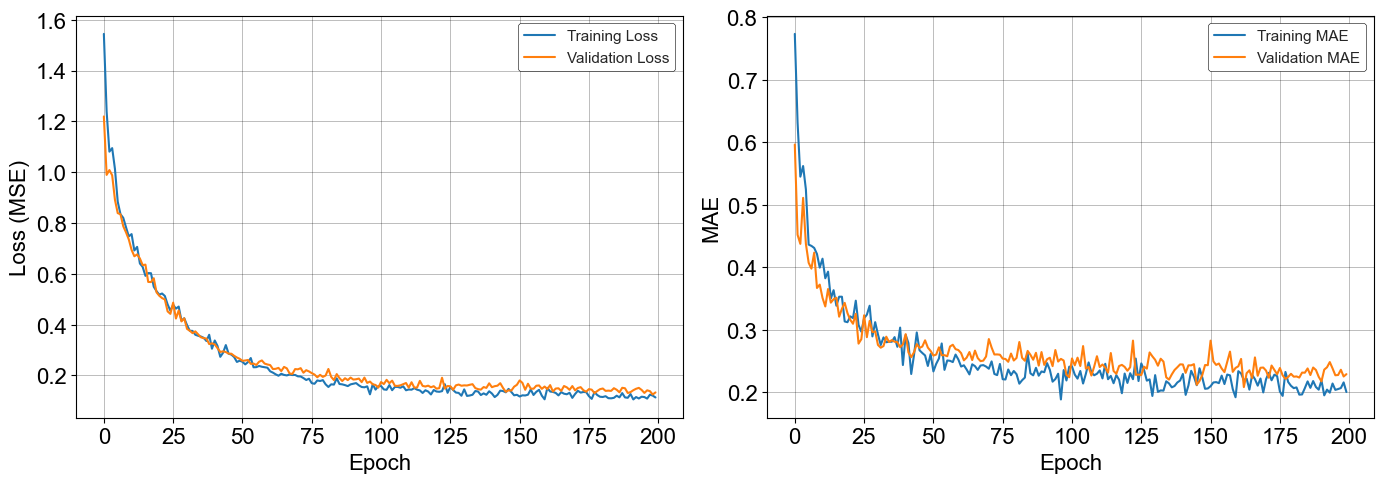

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Best NN model for a single run performance:

Performance metrics on the training set:
R² Score: 0.9492
MSE:      65.95
RMSE:     8.12%
MAE:      5.85%

Performance metrics on testing set:
R² Score: 0.8800
MSE:      149.87
RMSE:     12.24%
MAE:      8.47%


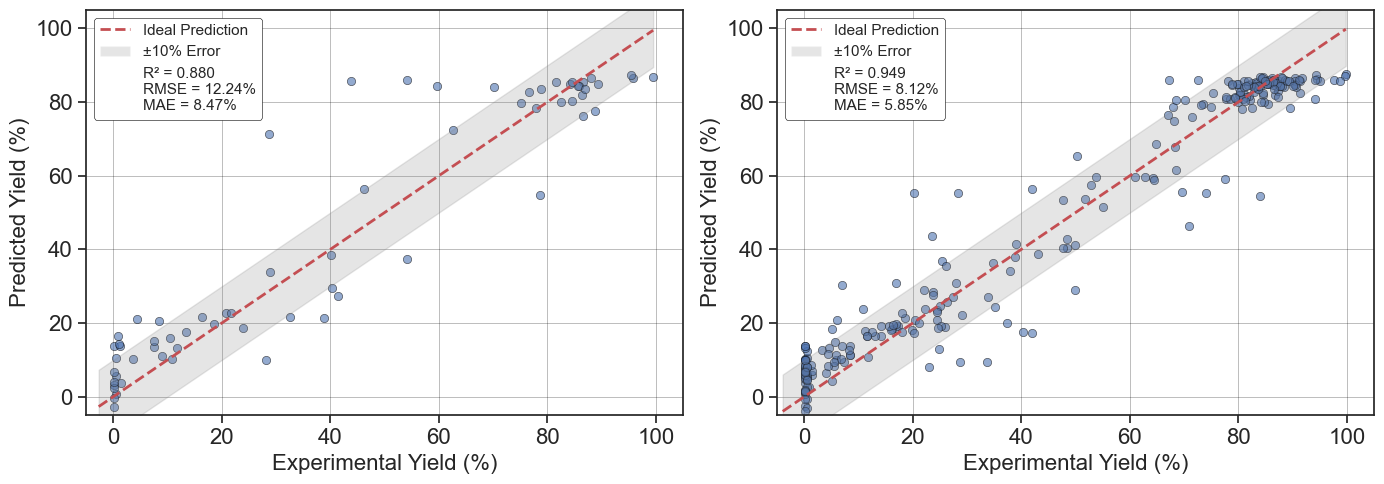

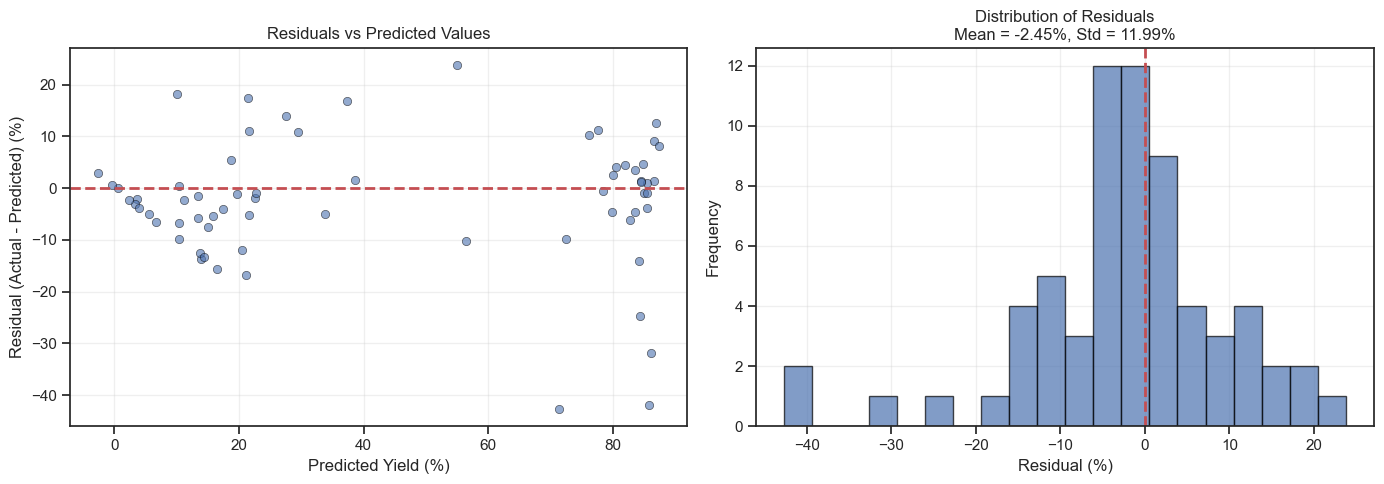

In [16]:
# Training history
training_validation_history_plot(history_best)

# Predication for the train and test set
Y_train_best_nn_pred = Y_scaler.inverse_transform(
    nn_best_model.predict(X_train_processed)).flatten()
Y_test_best_nn_pred  = Y_scaler.inverse_transform(
    nn_best_model.predict(X_test_processed)).flatten()

# Performance metrics
print("Best NN model for a single run performance:")
performance_metrics(Y_train, Y_train_best_nn_pred, Y_test, Y_test_best_nn_pred)

# Parity plot
parity_plot(Y_train, Y_train_best_nn_pred, Y_test, Y_test_best_nn_pred)

# Residual analysis
residual_analysis(Y_test, Y_test_best_nn_pred)

#### Cross validation of the Optuna best model

In [ ]:
def run_cross_validation_best_nn(X, Y, params, n_splits=5,
                                  random_state=random_number_seed):
    
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    mae_per_fold_test,  mae_per_fold_train, rmse_per_fold_train  = [], [], []
    r2_per_fold_test,   r2_per_fold_train, rmse_per_fold_test   = [], [], []

    n_layers     = params['n_layers']
    batch_size   = params['batch_size']

    for fold_no, (train_idx, test_idx) in enumerate(cv.split(X, Y), start=1):
        print(f'Training for fold {fold_no}/{n_splits}')

        train_X_raw_unsp = X.iloc[train_idx] # unsp: unsplit data
        test_X_raw_unsp = X.iloc[test_idx] # raw: not transformed or processed
        train_Y_raw_unsp = Y[train_idx]
        test_Y_raw_unsp = Y[test_idx]

        # This replaces validation_split=0.2 inside model.fit(). And is better because other takes last 20% of data
        train_X_raw, val_X_raw, train_Y_raw, val_Y_raw = train_test_split(
            train_X_raw_unsp, train_Y_raw_unsp, test_size=0.2, random_state=random_state
        )

        # Preprocessing — fit inside fold to avoid data leakage
        fold_preprocessor = ColumnTransformer(
            transformers=[('num', StandardScaler(), numerical_cols)])
        
        train_X = fold_preprocessor.fit_transform(train_X_raw)
        val_X   = fold_preprocessor.transform(val_X_raw)  
        test_X  = fold_preprocessor.transform(test_X_raw_unsp)

        # Scale Y — also fit only on inner training data
        fold_Y_scaler = StandardScaler()
        train_Y = fold_Y_scaler.fit_transform(train_Y_raw.reshape(-1, 1)).flatten()
        val_Y   = fold_Y_scaler.transform(val_Y_raw.reshape(-1, 1)).flatten()

        # Build & train
        fold_model = create_best_nn_model(train_X.shape[1], params)
        fold_early_stop = EarlyStopping(monitor='val_loss', patience=50,
                                restore_best_weights=True, verbose=1)
        fold_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.75,
                                    patience=20, min_lr=1e-5, verbose=1)

        history_fold = fold_model.fit(
            train_X, train_Y,
            validation_data=(val_X, val_Y), epochs=200, batch_size=batch_size,
            callbacks=[fold_early_stop, fold_reduce_lr], verbose=1, shuffle=True
        )

        # Inverse-scale predictions
        test_pred  = fold_Y_scaler.inverse_transform(
                         fold_model.predict(test_X,  verbose=0)).flatten()
        train_pred = fold_Y_scaler.inverse_transform(
                         fold_model.predict(train_X, verbose=0)).flatten()

        mae_test  = np.mean(np.abs(test_pred  - test_Y_raw_unsp))
        mae_train = np.mean(np.abs(train_pred - train_Y_raw))
        
        r2_test   = r2_score(test_Y_raw_unsp, test_pred)
        r2_train  = r2_score(train_Y_raw, train_pred)

        rmse_test = np.sqrt(mean_squared_error(test_Y_raw_unsp, test_pred))
        rmse_train = np.sqrt(mean_squared_error(train_Y_raw, train_pred))

        mae_per_fold_test.append(mae_test);  mae_per_fold_train.append(mae_train)
        r2_per_fold_test.append(r2_test);    r2_per_fold_train.append(r2_train)
        rmse_per_fold_test.append(rmse_test);  rmse_per_fold_train.append(rmse_train)

        print(f"Test  R² = {r2_test:.3f}  |  MAE = {mae_test:.2f}% |  RMSE = {rmse_test:.2f}%")
        print(f"Train R² = {r2_train:.3f}  |  MAE = {mae_train:.2f}% |  RMSE = {rmse_train:.2f}%")

        # Parity plot per fold
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, actual, predicted, label, r2v, maev in [
            (axes[0], test_Y_raw_unsp,  test_pred,  'Test',  r2_test,  mae_test),
            (axes[1], train_Y_raw, train_pred, 'Train', r2_train, mae_train),
        ]:
            ax.scatter(actual, predicted, alpha=0.6, edgecolors='black', linewidth=0.5)
            lo, hi = min(actual.min(), predicted.min()), max(actual.max(), predicted.max())
            ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal')
            ax.set_xlabel('Experimental Yield (%)', fontsize=12)
            ax.set_ylabel('Predicted Yield (%)',    fontsize=12)
            ax.set_title(
                f'Parity Plot – {label} Set  |  Fold {fold_no}\n'
                f'R² = {r2v:.3f},  MAE = {maev:.2f}%', fontsize=12)
            ax.legend(); ax.grid(True, alpha=0.3)
            ax.set_xlim(-10, 110); ax.set_ylim(-10, 110)
        plt.tight_layout(); plt.show()

        # Training / validation loss per fold
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(history_fold.history['loss'],     label='Train Loss')
        axes[0].plot(history_fold.history['val_loss'], label='Val Loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title(f'Loss – Fold {fold_no}')
        axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(history_fold.history['mae'],     label='Train MAE')
        axes[1].plot(history_fold.history['val_mae'], label='Val MAE')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
        axes[1].set_title(f'MAE – Fold {fold_no}')
        axes[1].legend(); axes[1].grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    return r2_per_fold_test, r2_per_fold_train, mae_per_fold_test, mae_per_fold_train, rmse_per_fold_test, rmse_per_fold_train

In [ ]:
r2_test_best, r2_train_best, mae_test_best, mae_train_best, rmse_test_best, rmse_train_best = \
    run_cross_validation_best_nn(X_train, Y_train, best_params_nn, n_splits=5)

print(f'\nBest NN — 5-fold CV results (test):')
print(f'MAE: {np.mean(mae_test_best):.2f}% ± {np.std(mae_test_best):.2f}%')
print(f'R²:  {np.mean(r2_test_best)*100:.2f}% ± {np.std(r2_test_best)*100:.3f}%')
print(f'RMSE: {np.mean(rmse_test_best):.2f}% ± {np.std(rmse_test_best):.2f}%')

print(f'\nBest NN — 5-fold CV results (train):')
print(f'MAE: {np.mean(mae_train_best):.2f}% ± {np.std(mae_train_best):.2f}%')
print(f'R²:  {np.mean(r2_train_best)*100:.2f}% ± {np.std(r2_train_best)*100:.3f}%')
print(f'RMSE: {np.mean(rmse_train_best):.2f}% ± {np.std(rmse_train_best):.2f}%')

#### SHAP-analysis of the Optuna best model

In [ ]:
background = X_train_processed
explainer = shap.GradientExplainer(nn_best_model, background)
shap_values_raw = explainer.shap_values(X_test_processed)

# Handle both old SHAP (returns list) and new SHAP (returns array directly)
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[0]   # old: list of arrays, one per output
else:
    shap_vals = shap_values_raw      # new: array directly, shape (n_samples, n_features)

# Squeeze in case of shape (n_samples, n_features, 1)
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

print(f"SHAP values shape: {shap_vals.shape}")         # should be (n_test, n_features)
print(f"X_test_processed shape: {X_test_processed.shape}")  # should match

In [ ]:
shap.summary_plot(shap_vals, X_test_processed, feature_names=feature_names, plot_type='bar', show=True)

In [ ]:
# Beeswarm plot
shap.summary_plot(shap_vals, X_test_processed, feature_names=feature_names, show=True)

In [ ]:
# Tabular ranking
shap_importance = pd.DataFrame({
    'descriptor': feature_names,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(shap_importance)

##### Outlier analysation

In [34]:
results_check = pd.DataFrame({
    'y_true': Y_test,
    'y_pred': Y_test_best_nn_pred,
    'residual': Y_test - Y_test_best_nn_pred,
    'abs_residual': np.abs(Y_test - Y_test_best_nn_pred),
    'ligand' : df_remaining['catalyst'],
    'time': df_remaining['time_s'],
    'temperautre': df_remaining['temp_c'],
    'cat loading': df_remaining['cat_loading'],
    'aryl halide': df_remaining['name_aryl_halide'],
    'boron species': df_remaining['name_boron_species']
}, index=X_test.index)

# Find outliers
outliers = results_check.nlargest(10, 'abs_residual')
# # Look them up in the orginal dataframe
# original_df.loc[outliers.index]

In [35]:
import plotly.express as px
results_check['original_index'] = results_check.index
fig = px.scatter(results_check, x='y_true', y='y_pred', hover_data=['original_index', 'residual'], title='Predicted vs Actual Yields with Residuals')
fig.add_shape(type='line', x0=0, y0=0, x1=100, y1=100, line=dict(color='Red', dash='dash'))
fig.show()

print(outliers)

     y_true     y_pred   residual  abs_residual ligand   time  temperautre  \
211    43.9  82.077766 -38.177766     38.177766  P2-L1   60.0        110.0   
298    28.7  59.127239 -30.427239     30.427239  P2-L1  150.3         71.6   
358    54.2  83.309456 -29.109456     29.109456  P1-L1   60.0        110.0   
75     78.7  56.034084  22.665916     22.665916  P1-L1  242.8        110.0   
52     38.8  17.980658  20.819342     20.819342  P1-L5  600.0        110.0   
208    59.7  79.700211 -20.000211     20.000211  P2-L1  160.9        110.0   
119    28.1   8.277118  19.822882     19.822882  P1-L7  149.0        110.0   
284     0.8  19.383835 -18.583835     18.583835  P1-L7  600.0         65.3   
51     41.4  24.877075  16.522925     16.522925  P1-L1  600.0        110.0   
348    99.5  84.704376  14.795624     14.795624  P1-L2  276.4         69.3   

     cat loading       aryl halide  \
211        1.413  3-chloropyridine   
298        1.037  2-chloropyridine   
358        0.977  2-chlorop

##### Extrapolatability test Perera

KRAKEN database dictionary: {'CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1': {'sphericity_boltz': 0.704737109, 'vbur_vbur_boltz': 105.5662868, 'sterimol_burB5_boltz': 7.439480407, 'fmo_eta_boltz': 0.193131047, 'fmo_omega_boltz': 0.03833597, 'fukui_m_boltz': 0.363743942999999}, 'COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.732618381, 'vbur_vbur_boltz': 101.0938553, 'sterimol_burB5_boltz': 7.15627618299999, 'fmo_eta_boltz': 0.196400018999999, 'fmo_omega_boltz': 0.033749737, 'fukui_m_boltz': 0.355754061}, 'CC(C)(C)P(C(C)(C)C)C(C)(C)C': {'sphericity_boltz': 0.889512, 'vbur_vbur_boltz': 65.12848283, 'sterimol_burB5_boltz': 4.894739112, 'fmo_eta_boltz': 0.25289, 'fmo_omega_boltz': 0.016170053, 'fukui_m_boltz': 0.63368}, 'CCCCP(C12CC3CC(CC(C3)C1)C2)C12CC3CC(CC(C3)C1)C2': {'sphericity_boltz': 0.781771957, 'vbur_vbur_boltz': 64.29165019, 'sterimol_burB5_boltz': 6.61531294399999, 'fmo_eta_boltz': 0.237805293999999, 'fmo_omega_boltz': 0.0202438089999999, 'fukui

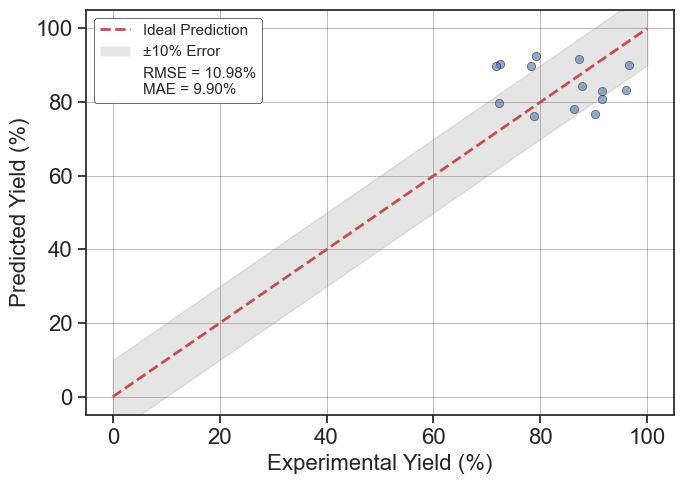

In [ ]:
# Loading the Perera dataset
path_perera_dataset = r"Perera_database - COMPLETE - BASELINE.xlsx"
df_perera = pd.read_excel(path_perera_dataset)

# Selecting specific data that matches the Reizman dataset.
df_perera = df_perera[df_perera['name_solvent'] == 'THF']
# df_perera = df_perera[df_perera['catalyst'].isin(['XPhos', 'SPhos', 'P(Cy)3', 'P(Ph)3', 'P(tBu)3'])]
df_perera = df_perera[df_perera['name_base'].isin(['NaOH'])] # NaOH very similar, KOH also pretty okay

# Adding the ligand descriptors from the KRAKEN
# Call the function with chosen ligand descriptors
append_ligand_descriptors(df_perera, df_kraken, selected_ligand_descriptor_list)

# Selecting the aryl and boron descriptors
selected_aryl_boron_descriptors = select_aryl_boron_solvent_descriptors(df_perera, selected_aryl_descriptor_list, selected_boron_descriptor_list, selected_solvent_descriptor_list)

# Delete the datapoints where there is a missing value for either ligands or base, because the model cannot learn from missing values and there are only a few datapoints with missing values.
df_perera_remaining = df_perera.dropna(subset=['ligand_smiles', 'smiles_base'])

# Check how much was removed
original_count = len(df_perera)
remaining_count = len(df_perera_remaining)
removed_count = original_count - remaining_count
removed_percent = (removed_count / original_count) * 100

print(f"Original rows: {original_count}")
print(f"Rows after removal: {remaining_count}")
print(f"Removed rows: {removed_count} ({removed_percent:.1f}%)")
print(f"Removed {removed_percent:.1f}% of data")

# Seperation of features (inputs) and targets (outputs) of the model
X_perera = df_perera_remaining.drop(['yield_pct', 'ligand_smiles', 'catalyst',
                       'name_aryl_halide', 'smiles_aryl_halide', 'name_boron_species',
                      'smiles_boron_species', 'name_base', 'smiles_base', 'name_solvent',
                       'smiles_solvent', 'number_reaction', 'precatalyst'], axis = 1)
Y_perera = df_perera_remaining['yield_pct'].values

# Scaling the features
perera_X_scaler = StandardScaler()
perera_Y_scaler = StandardScaler()

X_perera_scaled = perera_X_scaler.fit_transform(X_perera)
Y_perera_scaled = perera_Y_scaler.fit_transform(Y_perera.reshape(-1, 1)).flatten()

# Checking the shape
print(f"\nProcessed feature matrix shape: {X_perera_scaled.shape}")

# Now predict the Perera dataset with the best NN model trained on the Reizman dataset
Y_perera_pred = perera_Y_scaler.inverse_transform(
    nn_best_model.predict(X_perera_scaled)).flatten()

# Evaluate performance on the Perera dataset
performance_metrics(Y_perera, Y_perera_pred, Y_perera, Y_perera_pred)

# Plot the results
parity_plot_single(Y_perera, Y_perera_pred)